# Cyclic Encoding & Discretization

This notebook covers two feature engineering techniques:

| Technique | Purpose |
|---|---|
| **Cyclic Encoding** (sin/cos) | Preserves the circular nature of time-based features (e.g., hours, months) |
| **Discretization** | Converts continuous numerical features into ordinal bins via equal-width, equal-frequency, or uniform strategies |

## 1. Imports & Setup

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import KBinsDiscretizer

sns.set_theme(style="whitegrid")

## 2. Load Dataset

In [ ]:
df = pd.read_csv("Train.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


## 3. Cyclic Encoding

### 3.1 Simulate `Order_Hour` Feature

The original dataset does not contain a time-of-day column, so we simulate one.
Hours are cyclic — hour `23` is just one step away from hour `0` — which linear encoding cannot capture.

In [ ]:
np.random.seed(42)
df['Order_Hour'] = np.random.randint(0, 24, df.shape[0])

df[['Order_Hour']].head()

,Order_Hour
0,6
1,19
2,14
3,10
4,7


### 3.2 Apply Sin / Cos Transformation

$$\text{sin} = \sin\!\left(\frac{2\pi \cdot \text{hour}}{24}\right), \quad \text{cos} = \cos\!\left(\frac{2\pi \cdot \text{hour}}{24}\right)$$

Together, these two components uniquely identify every hour on the clock cycle.

In [ ]:
df['Hour_sin'] = np.sin(2 * np.pi * df['Order_Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Order_Hour'] / 24)

df[['Order_Hour', 'Hour_sin', 'Hour_cos']].head()

,Order_Hour,Hour_sin,Hour_cos
0,6,1.000000,6.123234e-17
1,19,-0.965926,2.588190e-01
2,14,-0.500000,-8.660254e-01
3,10,0.500000,-8.660254e-01
4,7,0.965926,-2.588190e-01


### 3.3 Visualise the Clock Circle

When plotted, sin/cos values form a unit circle — confirming that the cyclic structure of hours is preserved.

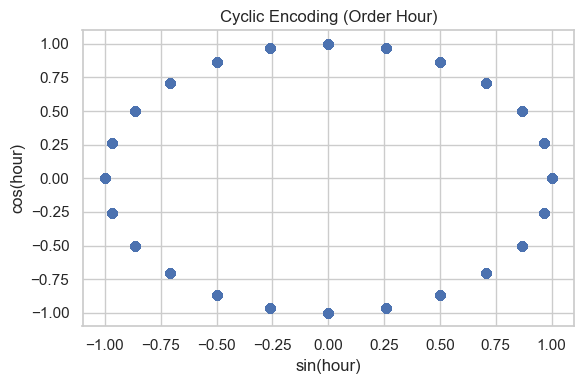

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(df['Hour_sin'], df['Hour_cos'], alpha=0.5)
plt.title("Cyclic Encoding (Order Hour)")
plt.xlabel("sin(hour)")
plt.ylabel("cos(hour)")
plt.tight_layout()
plt.show()

## 4. Discretization

Discretization bins a continuous variable into discrete intervals. Three strategies are compared below using `Cost_of_the_Product`.

| Method | Description |
|---|---|
| `pd.cut` | Equal-width bins |
| `pd.qcut` | Equal-frequency (quantile) bins |
| `KBinsDiscretizer` | sklearn-compatible; supports uniform, quantile, or k-means strategies |

### 4.1 Equal-Width Binning — `pd.cut`

In [ ]:
df['Cost_Bin_Width'] = pd.cut(df['Cost_of_the_Product'], bins=4)

df[['Cost_of_the_Product', 'Cost_Bin_Width']].head()

,Cost_of_the_Product,Cost_Bin_Width
0,177,"(149.5, 203.0]"
1,216,"(203.0, 256.5]"
2,183,"(149.5, 203.0]"
3,176,"(149.5, 203.0]"
4,184,"(149.5, 203.0]"


### 4.2 Equal-Frequency Binning — `pd.qcut`

In [ ]:
df['Cost_Bin_Freq'] = pd.qcut(df['Cost_of_the_Product'], q=4)

df[['Cost_of_the_Product', 'Cost_Bin_Freq']].head()

,Cost_of_the_Product,Cost_Bin_Freq
0,177,"(169.0, 214.0]"
1,216,"(214.0, 251.0]"
2,183,"(169.0, 214.0]"
3,176,"(169.0, 214.0]"
4,184,"(169.0, 214.0]"


### 4.3 Sklearn `KBinsDiscretizer` (Uniform Strategy)

In [ ]:
kbd = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='uniform')

df['Cost_Bin_KBins'] = kbd.fit_transform(df[['Cost_of_the_Product']])

df[['Cost_of_the_Product', 'Cost_Bin_KBins']].head()

,Cost_of_the_Product,Cost_Bin_KBins
0,177,1.0
1,216,2.0
2,183,1.0
3,176,1.0
4,184,1.0


### 4.4 Visualise Bin Distribution

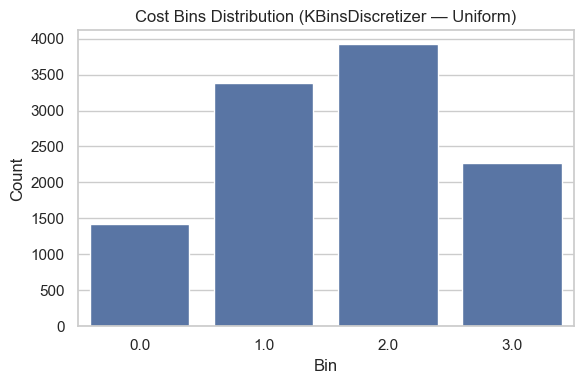

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Cost_Bin_KBins', data=df)
plt.title("Cost Bins Distribution (KBinsDiscretizer — Uniform)")
plt.xlabel("Bin")
plt.ylabel("Count")
plt.tight_layout()
plt.show()